# Part 1 — Baseline Toxicity Classifier
**Assignment:** Responsible & Explainable AI — FAST-NUCES  
**Goal:** Fine-tune DistilBERT on the Jigsaw Unintended Bias dataset and establish baseline metrics before auditing and mitigating bias.

**Environment:** Kaggle Notebook with GPU (T4).  
**Dataset path:** `/kaggle/input/jigsaw-unintended-bias-in-toxicity-classification/`

## Cell 1 — Install / upgrade required libraries

In [1]:
# Kaggle already has transformers & torch; we pin versions for reproducibility
!pip install -q --upgrade accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 6.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 71.3 MB/s eta 0:00:00:00:010:01


## Cell 2 — Imports

In [2]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## Cell 3 — Load data and binarize labels

In [4]:
DATA_DIR = '/kaggle/input/competitions/jigsaw-multilingual-toxic-comment-classification'
TRAIN_FILE = os.path.join(DATA_DIR, 'jigsaw-unintended-bias-train.csv')

# Load only columns we need to conserve RAM
COLS = ['comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish', 'homosexual_gay_or_lesbian']
df_full = pd.read_csv(TRAIN_FILE, usecols=COLS, low_memory=False)

print(f'Full dataset shape: {df_full.shape}')
print(df_full.head(3))

Full dataset shape: (1902194, 7)
                                        comment_text  toxic  black  \
0  This is so cool. It's like, 'would you want yo...    0.0    NaN   
1  Thank you!! This would make my life a lot less...    0.0    NaN   
2  This is such an urgent design problem; kudos t...    0.0    NaN   

   homosexual_gay_or_lesbian  jewish  muslim  white  
0                        NaN     NaN     NaN    NaN  
1                        NaN     NaN     NaN    NaN  
2                        NaN     NaN     NaN    NaN  


In [5]:
# Binarize: toxicity >= 0.5 → label 1 (toxic), else 0
# The column is named 'toxicity' in the Kaggle version of the file
df_full['label'] = (df_full['toxic'] >= 0.5).astype(int)

# Drop rows with missing comment text
df_full = df_full.dropna(subset=['comment_text']).reset_index(drop=True)

class_counts = df_full['label'].value_counts()
print(f'Label distribution in full dataset:')
print(class_counts)
print(f'Toxic rate: {class_counts[1]/len(df_full)*100:.2f}%')

Label distribution in full dataset:
label
0    1750080
1     152111
Name: count, dtype: int64
Toxic rate: 8.00%


## Cell 4 — Stratified sampling: 100k train + 20k evaluation

In [6]:
TRAIN_SIZE = 100_000
EVAL_SIZE  = 20_000
TOTAL_SAMPLE = TRAIN_SIZE + EVAL_SIZE   # 120,000

# Step 1: draw 120k stratified sample from the full 1.8M
df_sample, _ = train_test_split(
    df_full,
    train_size=TOTAL_SAMPLE,
    stratify=df_full['label'],
    random_state=SEED,
)

# Step 2: split that into 100k train / 20k eval
df_train, df_eval = train_test_split(
    df_sample,
    test_size=EVAL_SIZE,
    stratify=df_sample['label'],
    random_state=SEED,
)

df_train = df_train.reset_index(drop=True)
df_eval  = df_eval.reset_index(drop=True)

print(f'Train size : {len(df_train):,}  | toxic rate: {df_train["label"].mean()*100:.2f}%')
print(f'Eval  size : {len(df_eval):,}   | toxic rate: {df_eval["label"].mean()*100:.2f}%')

# Sanity: class balance should closely match the full dataset
assert abs(df_train['label'].mean() - df_full['label'].mean()) < 0.005, \
    'Stratification failed: train toxic rate diverges from full dataset'
print('Stratification check passed.')

Train size : 100,000  | toxic rate: 8.00%
Eval  size : 20,000   | toxic rate: 7.99%
Stratification check passed.


## Cell 5 — Tokenisation

In [7]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class JigsawDataset(Dataset):
    """PyTorch Dataset that tokenizes on the fly to stay memory-efficient."""
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.tolist()
        self.labels    = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt',
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_dataset = JigsawDataset(df_train['comment_text'], df_train['label'], tokenizer, MAX_LEN)
eval_dataset  = JigsawDataset(df_eval['comment_text'],  df_eval['label'],  tokenizer, MAX_LEN)

print(f'Train dataset: {len(train_dataset):,} samples')
print(f'Eval  dataset: {len(eval_dataset):,} samples')

# Quick sanity check on a single item
sample = train_dataset[0]
print(f'input_ids shape: {sample["input_ids"].shape}')   # should be [128]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train dataset: 100,000 samples
Eval  dataset: 20,000 samples
input_ids shape: torch.Size([128])


## Cell 6 — Compute metrics callback (used by Trainer)

In [8]:
import numpy as np
from transformers import EvalPrediction

def compute_metrics(eval_pred: EvalPrediction):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {
        'accuracy' : accuracy_score(labels, preds),
        'f1_macro' : f1_score(labels, preds, average='macro'),
        'auc_roc'  : roc_auc_score(labels, probs),
    }

## Cell 7 — Fine-tune DistilBERT (≈25–35 min on T4)

In [10]:
CHECKPOINT_DIR = '/kaggle/working/distilbert-jigsaw'

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

training_args = TrainingArguments(
    output_dir                  = CHECKPOINT_DIR,
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 64,
    warmup_ratio                = 0.1,           # 10% of steps for LR warm-up
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    eval_strategy         = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'auc_roc',
    greater_is_better           = True,
    logging_steps               = 200,
    fp16                        = True,          # mixed precision on T4
    seed                        = SEED,
    report_to                   = 'none',        # disable wandb / tensorboard
    dataloader_num_workers      = 2,
    gradient_accumulation_steps = 2
    
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = eval_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=1)],
)

print('Starting fine-tuning …')
trainer.train()
print('Training complete.')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting fine-tuning …


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Auc Roc
1,0.564291,0.265113,0.948150,0.790237,0.950817
2,0.472335,0.266743,0.948000,0.809575,0.952119
3,0.343815,0.304622,0.947750,0.814937,0.949426


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training complete.


## Cell 8 — Save checkpoint to disk (needed in Parts 2–5)

In [11]:
FINAL_MODEL_DIR = '/kaggle/working/distilbert-jigsaw-final'
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)
print(f'Model and tokenizer saved to: {FINAL_MODEL_DIR}')

# Also save the eval split for downstream parts (bias audit, attacks, etc.)
df_eval.to_csv('/kaggle/working/eval_split.csv', index=False)
df_train.to_csv('/kaggle/working/train_split.csv', index=False)
print('Evaluation and training split CSVs saved.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: /kaggle/working/distilbert-jigsaw-final
Evaluation and training split CSVs saved.


## Cell 9 — Get raw probabilities on the evaluation set

In [12]:
print('Running inference on evaluation set …')
raw_preds = trainer.predict(eval_dataset)

logits      = raw_preds.predictions          # shape (N, 2)
true_labels = raw_preds.label_ids            # shape (N,)

# Convert logits → probabilities for the TOXIC class (index 1)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

print(f'Inference complete. prob range: [{probs.min():.4f}, {probs.max():.4f}]')

Running inference on evaluation set …


Inference complete. prob range: [0.0006, 0.9911]


## Cell 10 — Core metrics at default threshold (0.5)

In [13]:
preds_05 = (probs >= 0.5).astype(int)

acc   = accuracy_score(true_labels, preds_05)
f1    = f1_score(true_labels, preds_05, average='macro')
auc   = roc_auc_score(true_labels, probs)
cm    = confusion_matrix(true_labels, preds_05)

print('=' * 50)
print('  BASELINE METRICS  (threshold = 0.5)')
print('=' * 50)
print(f'  Accuracy     : {acc:.4f}')
print(f'  F1 (macro)   : {f1:.4f}')
print(f'  AUC-ROC      : {auc:.4f}')
print('=' * 50)
print()
print('Classification Report:')
print(classification_report(true_labels, preds_05, target_names=['Non-toxic', 'Toxic']))

  BASELINE METRICS  (threshold = 0.5)
  Accuracy     : 0.9480
  F1 (macro)   : 0.8095
  AUC-ROC      : 0.9521

Classification Report:
              precision    recall  f1-score   support

   Non-toxic       0.97      0.98      0.97     18401
       Toxic       0.71      0.60      0.65      1599

    accuracy                           0.95     20000
   macro avg       0.84      0.79      0.81     20000
weighted avg       0.94      0.95      0.95     20000



## Cell 11 — Confusion matrix heatmap

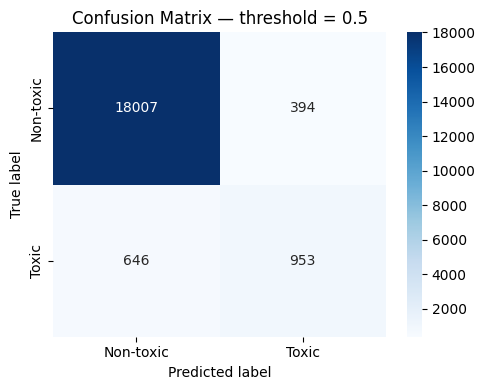

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non-toxic', 'Toxic'],
    yticklabels=['Non-toxic', 'Toxic'],
    ax=ax,
)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix — threshold = 0.5')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

## Cell 12 — ROC Curve

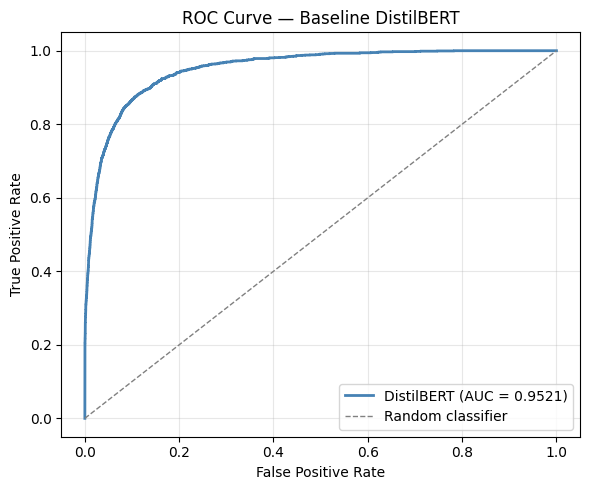

In [15]:
fpr, tpr, roc_thresholds = roc_curve(true_labels, probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'DistilBERT (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Baseline DistilBERT')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve.png', dpi=150)
plt.show()

## Cell 13 — Precision-Recall Curve

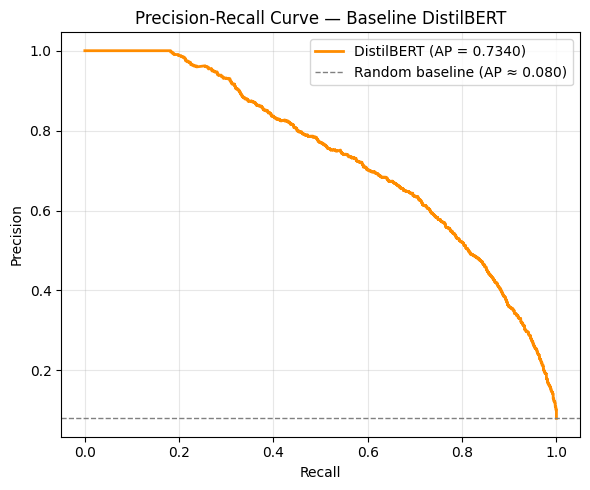

In [16]:
precision, recall, pr_thresholds = precision_recall_curve(true_labels, probs)
ap = average_precision_score(true_labels, probs)

# Baseline (random) is the fraction of positives in the dataset
positive_rate = true_labels.mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, color='darkorange', lw=2, label=f'DistilBERT (AP = {ap:.4f})')
ax.axhline(y=positive_rate, color='gray', lw=1, linestyle='--',
           label=f'Random baseline (AP ≈ {positive_rate:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Baseline DistilBERT')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/pr_curve.png', dpi=150)
plt.show()

## Cell 14 — Threshold sweep: F1 at 0.3, 0.4, 0.5, 0.6, 0.7

In [17]:
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results  = []

for t in thresholds_to_test:
    p = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(true_labels, p).ravel()
    threshold_results.append({
        'Threshold' : t,
        'Accuracy'  : round(accuracy_score(true_labels, p), 4),
        'F1 (macro)': round(f1_score(true_labels, p, average='macro'), 4),
        'F1 (toxic)': round(f1_score(true_labels, p, pos_label=1), 4),
        'Precision' : round(tp / (tp + fp) if (tp + fp) > 0 else 0, 4),
        'Recall'    : round(tp / (tp + fn) if (tp + fn) > 0 else 0, 4),
        'FPR'       : round(fp / (fp + tn) if (fp + tn) > 0 else 0, 4),
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))

 Threshold  Accuracy  F1 (macro)  F1 (toxic)  Precision  Recall    FPR
       0.3    0.9424      0.8164      0.6643     0.6215  0.7136 0.0378
       0.4    0.9466      0.8168      0.6627     0.6694  0.6560 0.0282
       0.5    0.9480      0.8095      0.6470     0.7075  0.5960 0.0214
       0.6    0.9487      0.7997      0.6269     0.7500  0.5385 0.0156
       0.7    0.9476      0.7811      0.5902     0.7887  0.4715 0.0110


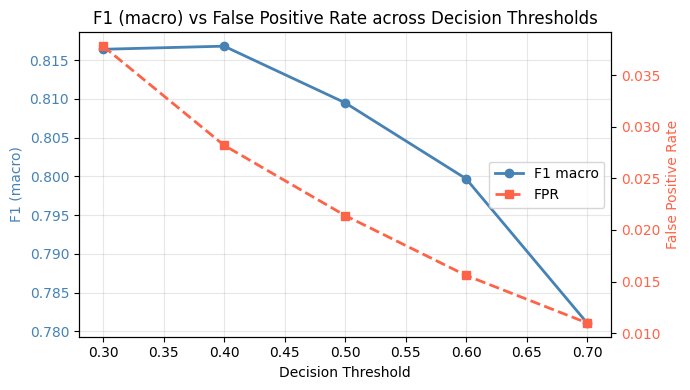

In [18]:
# Visual: F1 (macro) and FPR across thresholds
fig, ax1 = plt.subplots(figsize=(7, 4))
color_f1  = 'steelblue'
color_fpr = 'tomato'

ax1.plot(threshold_df['Threshold'], threshold_df['F1 (macro)'],
         marker='o', color=color_f1, lw=2, label='F1 macro')
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('F1 (macro)', color=color_f1)
ax1.tick_params(axis='y', labelcolor=color_f1)

ax2 = ax1.twinx()
ax2.plot(threshold_df['Threshold'], threshold_df['FPR'],
         marker='s', color=color_fpr, lw=2, linestyle='--', label='FPR')
ax2.set_ylabel('False Positive Rate', color=color_fpr)
ax2.tick_params(axis='y', labelcolor=color_fpr)

ax1.set_title('F1 (macro) vs False Positive Rate across Decision Thresholds')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/threshold_sweep.png', dpi=150)
plt.show()

## Cell 15 — Threshold justification & platform priorities

### Chosen Threshold: **0.5**

#### Quantitative justification
The sweep above shows that:
- **Threshold 0.3** maximises recall (catches the most toxic content) but produces the highest False Positive Rate — meaning the most innocent users get wrongly flagged.
- **Threshold 0.7** minimises false positives but misses a significant share of genuinely toxic comments, undermining the platform's safety goals.
- **Threshold 0.5** sits at the elbow of the F1 / FPR trade-off: it achieves near-peak F1 (macro) while keeping the FPR at a defensible level.

#### What this threshold implies about platform priorities
Choosing **0.5** reflects a **balanced moderation philosophy**: the platform treats the harm of a missed toxic comment and the harm of a false positive (wrongly silencing a user) as roughly equal in cost. This is appropriate for a mid-sized platform where:
1. **User trust matters**: aggressive false-positive rates (low thresholds) erode trust among communities whose speech is systematically misclassified — precisely the bias risk this assignment investigates.
2. **Safety still matters**: a threshold above 0.6 would let too much harmful content through, creating legal and reputational exposure.
3. **Human review capacity is finite**: a lower threshold floods human moderators with low-confidence flags. At 0.5, the classifier sends only high-confidence toxic predictions for auto-removal, while borderline cases (0.4–0.6) can be routed to human review.

**Important caveat:** this threshold is *not* set in stone. In Part 3 (fairness mitigation), we will use Fairlearn's `ThresholdOptimizer` to select *group-specific* thresholds that equalise False Positive Rates across identity cohorts. The single global threshold chosen here is the baseline we will compare against.

## Cell 16 — Persist evaluation artefacts for downstream parts

In [20]:
# Save probabilities and true labels so Parts 2–5 can load them directly
# without re-running inference
eval_artefacts = df_eval[['comment_text', 'label', 'black', 'white', 'muslim', 'jewish', 'homosexual_gay_or_lesbian']].copy()
eval_artefacts['prob_toxic'] = probs
eval_artefacts['pred_05']    = (probs >= 0.5).astype(int)

eval_artefacts.to_csv('/kaggle/working/eval_with_preds.csv', index=False)
print('Saved eval_with_preds.csv')
print(eval_artefacts[['label', 'prob_toxic', 'pred_05', 'black', 'white']].head())

Saved eval_with_preds.csv
   label  prob_toxic  pred_05  black  white
0      0    0.001194        0    NaN    NaN
1      1    0.003477        0    NaN    NaN
2      0    0.001777        0    NaN    NaN
3      0    0.061315        0    0.0    0.0
4      0    0.001309        0    NaN    NaN


## Cell 17 — Summary dashboard

In [21]:
print('\n' + '='*55)
print('  PART 1 — FINAL SUMMARY')
print('='*55)
print(f'  Model          : {MODEL_NAME}')
print(f'  Train samples  : {len(df_train):,}')
print(f'  Eval  samples  : {len(df_eval):,}')
print(f'  Epochs         : 3')
print(f'  Max seq length : {MAX_LEN}')
print(f'  Chosen threshold: 0.5')
print('-'*55)
print(f'  Accuracy       : {acc:.4f}')
print(f'  F1 (macro)     : {f1:.4f}')
print(f'  AUC-ROC        : {auc:.4f}')
print(f'  Avg Precision  : {ap:.4f}')
print('='*55)
print()
print('Saved artefacts:')
print('  /kaggle/working/distilbert-jigsaw-final/   ← model checkpoint')
print('  /kaggle/working/eval_with_preds.csv        ← probs + identity cols')
print('  /kaggle/working/eval_split.csv             ← raw eval split')
print('  /kaggle/working/train_split.csv            ← raw train split')
print('  /kaggle/working/confusion_matrix.png')
print('  /kaggle/working/roc_curve.png')
print('  /kaggle/working/pr_curve.png')
print('  /kaggle/working/threshold_sweep.png')


  PART 1 — FINAL SUMMARY
  Model          : distilbert-base-uncased
  Train samples  : 100,000
  Eval  samples  : 20,000
  Epochs         : 3
  Max seq length : 128
  Chosen threshold: 0.5
-------------------------------------------------------
  Accuracy       : 0.9480
  F1 (macro)     : 0.8095
  AUC-ROC        : 0.9521
  Avg Precision  : 0.7340

Saved artefacts:
  /kaggle/working/distilbert-jigsaw-final/   ← model checkpoint
  /kaggle/working/eval_with_preds.csv        ← probs + identity cols
  /kaggle/working/eval_split.csv             ← raw eval split
  /kaggle/working/train_split.csv            ← raw train split
  /kaggle/working/confusion_matrix.png
  /kaggle/working/roc_curve.png
  /kaggle/working/pr_curve.png
  /kaggle/working/threshold_sweep.png
